<div style="text-align: center;">

# Identification of transcriptional signatures associated with oxidative stress and chronic wound infection in Pseudomonas aeruginosa using RNA-seq data.

</div>

---

## Project overview

This project demonstrates a complete exploratory RNA-seq analysis pipeline using Python.

The objective is not to reproduce a publication-grade bioinformatics workflow, but to illustrate key data science skills applicable to complex datasets.

Skills demonstrated in this notebook include:

- data cleaning and structuring
- exploratory data analysis (EDA)
- dimensionality reduction (PCA)
- variance analysis and clustering
- statistical testing
- scientific data visualization
- interpretation of results

Although the dataset originates from a biological study (*Pseudomonas aeruginosa* response to oxidative stress), the primary focus is on building a clear and reproducible analytical pipeline.

# Introduction
    
*Pseudomonas aeruginosa* is an opportunistic bacterial pathogen frequently associated with chronic wound infections. A key factor contributing to its persistence in these environments is its ability to form biofilms, which protect bacterial populations from host immune responses and antimicrobial treatments.

Chronic wounds are characterized by high levels of **oxidative stress**, generated by the host immune system as a defense mechanism against microbial infection. However, *P. aeruginosa* can adapt to this hostile environment by activating specific genetic programs involved in stress resistance, communication between bacterial cells (quorum sensing), virulence, and biofilm formation.

To better understand these adaptive responses, transcriptomic approaches such as **RNA sequencing (RNA-seq)** are widely used. RNA-seq is a high-throughput technique that measures gene expression across the entire transcriptome, allowing researchers to quantify how actively each gene is expressed under different biological conditions.

In an RNA-seq experiment, messenger RNA (mRNA) molecules present in a sample are converted into complementary DNA (cDNA) and sequenced. The sequencing process generates millions of short fragments called **reads**, which are then mapped to a reference genome to determine the gene from which they originate.

For each gene, the number of reads that map to it is counted. These **read counts** provide an estimate of gene expression levels.

The resulting dataset can therefore be represented as a **gene expression matrix**, where:

- rows correspond to genes  
- columns correspond to biological samples  
- values correspond to read counts for each gene in each sample  

Because RNA-seq datasets measure expression levels for thousands of genes simultaneously, they are particularly well suited for statistical analysis and multivariate data exploration.

The dataset analyzed in this project contains gene expression measurements obtained from *Pseudomonas aeruginosa* samples collected under two experimental conditions:

- **CW** – bacteria collected from chronic wounds  
- **NC** – bacteria collected from non-chronic (control) wounds  

The central scientific question is whether these conditions produce distinct transcriptional profiles and which genes are involved in the bacterial response to oxidative stress and chronic infection.

To address this question, the analysis follows a structured workflow including exploratory data analysis, normalization and transformation of count data, correlation analysis, principal component analysis (PCA), and identification of genes associated with differences between conditions.

This project aims to demonstrate a complete and reproducible data analysis pipeline applied to RNA-seq data, combining biological interpretation with statistical and data science methods.



---

## Simplified RNA-seq workflow

DNA (genome)  

    ↓ transcription  
RNA molecules  

    ↓ sequencing  
Millions of sequencing reads 

    ↓ alignment to reference genome  
Reads mapped to genes

    ↓ counting  
Gene expression matrix (genes × samples)



In summary, RNA-seq experiments generate millions of sequencing reads derived from RNA molecules present in a sample. These reads are aligned to a reference genome, and the number of reads mapping to each gene is counted. The resulting **gene expression matrix** provides a quantitative estimate of gene activity across samples and serves as the starting point for downstream statistical analysis.


# Data description

The dataset analyzed in this project originates from an RNA sequencing (RNA-seq) experiment performed on the opportunistic pathogen *Pseudomonas aeruginosa*.

*Pseudomonas aeruginosa* is a bacterium frequently associated with chronic wound infections. One of its key pathogenic traits is its ability to form biofilms, which protect bacterial communities from host defenses and antimicrobial treatments.

In chronic wounds, bacteria are exposed to high levels of **oxidative stress**, generated by host immune responses. Understanding how *P. aeruginosa* adapts to this hostile environment is essential for identifying mechanisms involved in infection persistence and biofilm formation.

RNA-seq experiments allow researchers to quantify gene expression by sequencing RNA molecules present in biological samples. During sequencing, messenger RNA (mRNA) molecules are converted into complementary DNA and sequenced, producing millions of short fragments called **reads**. These reads are then aligned to a reference genome in order to determine the gene from which they originate.

The number of reads mapped to each gene is counted, producing **gene-level read counts** that provide an estimate of gene expression levels.

The resulting dataset can be represented as a **gene expression matrix**, where:

- rows correspond to genes
- columns correspond to biological samples
- values correspond to read counts for each gene in each sample

In this experiment, gene expression profiles were obtained from *Pseudomonas aeruginosa* samples collected under two conditions:

- **CW** – bacteria collected from chronic wounds
- **NC** – bacteria collected from non-chronic (control) wounds

Comparing gene expression between these conditions allows us to identify genes and biological pathways that are activated during infection and biofilm formation under oxidative stress.

The goal of the analysis is therefore to explore the structure of the RNA-seq dataset, assess similarities between samples, and identify genes whose expression differs between chronic and non-chronic wound conditions.

# Dataset summary

Organism: *Pseudomonas aeruginosa*  

Experiment type: RNA-seq gene expression profiling 

Conditions: 
- *Chronic wounds* (CW) vs *Non-chronic wounds* (NC)
- *three timepoints: 24h, 48h, 72h*
- *three biological replicates per condition and timepoint*

Total samples: 18
Total genes: ~6500

Biological context: <u>Response to oxidative stress during wound infection</u> 

Goal of the analysis: identify transcriptional changes associated with chronic wound infection and oxidative stress.

### Import Libraries and settings

In [14]:
# Import libraries

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Plot style
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8,5)

### Quick View on the datas

In [15]:
# Explore data directory
data_dir = "../data/raw"
os.listdir(data_dir)

['genomic.gff',
 'genomic.gff:Zone.Identifier',
 '.ipynb_checkpoints',
 'GSE267862_count_matrix.txt']

In [16]:
# Load the count matrix
df = pd.read_csv("../data/raw/GSE267862_count_matrix.txt", sep="\t", skiprows=1)
df.head()

,Geneid,CW24A,CW24B,CW24C,CW48A,CW48B,CW48C,CW72A,CW72B,CW72C,NC24A,NC24B,NC24C,NC48A,NC48B,NC48C,NC72A,NC72B,NC72C
0,EKIOKJ_00005.t01,329,276,1509,1105,1831,843,691,848,838,239,502,416,137,1316,176,803,99,1085
1,EKIOKJ_00010.t01,154,543,960,915,935,356,380,542,770,421,710,1124,57,538,1054,415,59,1120
2,EKIOKJ_00015.t01,241,339,1637,1149,1708,629,423,644,611,137,583,313,69,838,289,460,104,738
3,EKIOKJ_00020.t01,36,344,364,377,337,89,77,193,208,203,324,795,32,104,723,191,16,430
4,EKIOKJ_00025.t01,39,230,238,259,295,70,61,125,87,127,148,428,2,97,356,91,12,216


In [17]:
# Check dataset dimensions
df.shape

(6497, 19)

In [18]:
# Inspect column names
df.columns

Index(['Geneid', 'CW24A', 'CW24B', 'CW24C', 'CW48A', 'CW48B', 'CW48C', 'CW72A',
       'CW72B', 'CW72C', 'NC24A', 'NC24B', 'NC24C', 'NC48A', 'NC48B', 'NC48C',
       'NC72A', 'NC72B', 'NC72C'],
      dtype='object')

In [19]:
# Set Geneid as index
df2 = df.set_index("Geneid")

df2.head()

,CW24A,CW24B,CW24C,CW48A,CW48B,CW48C,CW72A,CW72B,CW72C,NC24A,NC24B,NC24C,NC48A,NC48B,NC48C,NC72A,NC72B,NC72C
Geneid,,,,,,,,,,,,,,,,,,
EKIOKJ_00005.t01,329,276,1509,1105,1831,843,691,848,838,239,502,416,137,1316,176,803,99,1085
EKIOKJ_00010.t01,154,543,960,915,935,356,380,542,770,421,710,1124,57,538,1054,415,59,1120
EKIOKJ_00015.t01,241,339,1637,1149,1708,629,423,644,611,137,583,313,69,838,289,460,104,738
EKIOKJ_00020.t01,36,344,364,377,337,89,77,193,208,203,324,795,32,104,723,191,16,430
EKIOKJ_00025.t01,39,230,238,259,295,70,61,125,87,127,148,428,2,97,356,91,12,216


### Removal of genes with zero counts

Genes that have zero counts across all samples do not contain any expression information and can be removed from the dataset before further analysis.

In [20]:
# Number of genes with zero counts across all samples
(df2.sum(axis=1)==0).sum()

np.int64(6)

In [21]:
# Remove genes with zero counts
df3 = df2[df2.sum(axis=1) != 0]
df3.head()

,CW24A,CW24B,CW24C,CW48A,CW48B,CW48C,CW72A,CW72B,CW72C,NC24A,NC24B,NC24C,NC48A,NC48B,NC48C,NC72A,NC72B,NC72C
Geneid,,,,,,,,,,,,,,,,,,
EKIOKJ_00005.t01,329,276,1509,1105,1831,843,691,848,838,239,502,416,137,1316,176,803,99,1085
EKIOKJ_00010.t01,154,543,960,915,935,356,380,542,770,421,710,1124,57,538,1054,415,59,1120
EKIOKJ_00015.t01,241,339,1637,1149,1708,629,423,644,611,137,583,313,69,838,289,460,104,738
EKIOKJ_00020.t01,36,344,364,377,337,89,77,193,208,203,324,795,32,104,723,191,16,430
EKIOKJ_00025.t01,39,230,238,259,295,70,61,125,87,127,148,428,2,97,356,91,12,216


# Exploratory Data Analysis (EDA)

Before performing normalization and downstream analyses, it is important to explore the structure of the RNA-seq dataset. Exploratory data analysis helps identify potential issues such as differences in sequencing depth between samples, highly skewed count distributions, or lowly expressed genes.

In this section, we examine basic properties of the dataset, including the total number of reads per sample and the distribution of gene expression counts.

## Library size

In [22]:
# Calculate library sizes
library_sizes = df3.sum(axis=0)

# CPM normalization
cpm = df3.div(library_sizes, axis=1) * 1e6

# Log transformation
log_cpm = np.log2(cpm + 1)

log_cpm.head()

,CW24A,CW24B,CW24C,CW48A,CW48B,CW48C,CW72A,CW72B,CW72C,NC24A,NC24B,NC24C,NC48A,NC48B,NC48C,NC72A,NC72B,NC72C
Geneid,,,,,,,,,,,,,,,,,,
EKIOKJ_00005.t01,3.996558,3.816457,5.933061,5.564406,6.360315,5.256795,5.106846,5.203650,5.030429,4.039042,4.827619,3.929931,2.950222,5.679739,3.228589,5.256838,2.557309,5.357554
EKIOKJ_00010.t01,3.000618,4.741489,5.294015,5.298520,5.407451,4.063856,4.278023,4.579813,4.912230,4.817405,5.312790,5.303028,1.925819,4.429394,5.676546,4.339402,1.967874,5.402258
EKIOKJ_00015.t01,3.580135,4.093917,6.048675,5.619571,6.261255,4.847104,4.425102,4.818994,4.590959,3.300111,5.036352,3.550328,2.133859,5.044567,3.882611,4.480936,2.616560,4.818002
EKIOKJ_00020.t01,1.398988,4.113811,3.953906,4.070699,3.994324,2.301887,2.241390,3.195283,3.147928,3.818992,4.223571,4.818457,1.362702,2.313783,5.145595,3.301111,0.839694,4.074896
EKIOKJ_00025.t01,1.471757,3.573758,3.389392,3.567682,3.815121,2.032741,1.983228,2.651846,2.100706,3.202251,3.182204,3.968302,0.135179,2.234046,4.164892,2.383968,0.671070,3.164005


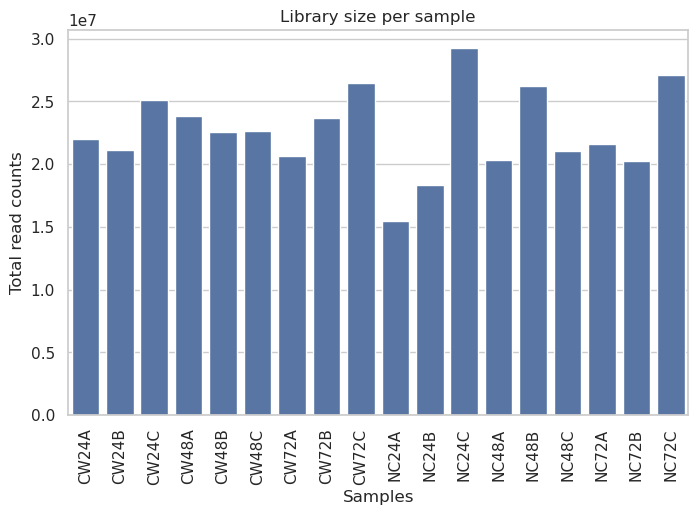

In [23]:
# Create a figure with a defined size
# figsize controls the width and height of the plot
plt.figure(figsize=(8,5))

# Create a barplot showing the sequencing depth (library size) for each sample
# library_size contains the total number of reads per sample
# x-axis: sample names
# y-axis: total number of reads mapped in each sample
sns.barplot(x=library_sizes.index, y=library_sizes.values)

# Rotate sample labels on the x-axis to improve readability
plt.xticks(rotation=90)

# Add title and axis labels
plt.title("Library size per sample")
plt.xlabel("Samples")
plt.ylabel("Total read counts")

# Display the plot
plt.show()

### Interpretation

The total number of reads per sample ranges from approximately 15 million to 29 million reads. Overall, sequencing depth appears relatively consistent across samples, indicating comparable library sizes.

One sample (NC24A) shows a slightly lower read count compared to the others, but the difference remains within an acceptable range for RNA-seq experiments. Therefore, no major sequencing depth imbalance is observed that would compromise downstream analyses.

## Distribution of raw counts

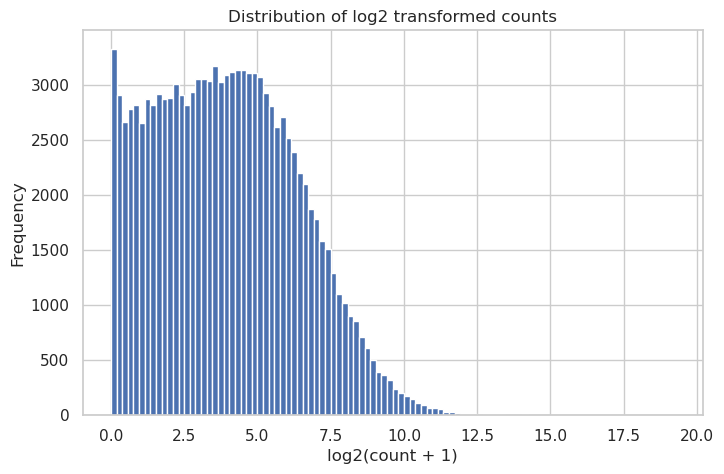

In [28]:
# Create a figure with a defined size
plt.figure(figsize=(8,5))

# Plot the distribution of all log-transformed counts
# values.flatten() converts the matrix into a single vector so that all expression values are included
# bins=100 defines the number of histogram bins
plt.hist(log_cpm.values.flatten(), bins=100)

# Add title and axis labels
plt.title("Distribution of log2 transformed counts")
plt.xlabel("log2(count + 1)")
plt.ylabel("Frequency")

# Display the histogram
plt.show()

### Interpretation

The distribution of log2-transformed counts shows a smooth, approximately unimodal shape centered around intermediate expression values. 

This pattern is typical of RNA-seq datasets, where most genes are expressed at moderate levels while a smaller number of genes show very high expression. The log2 transformation reduces the strong right-skewness of raw counts and makes the distribution more suitable for downstream statistical analyses and visualization.

## Distribution of gene expression per sample

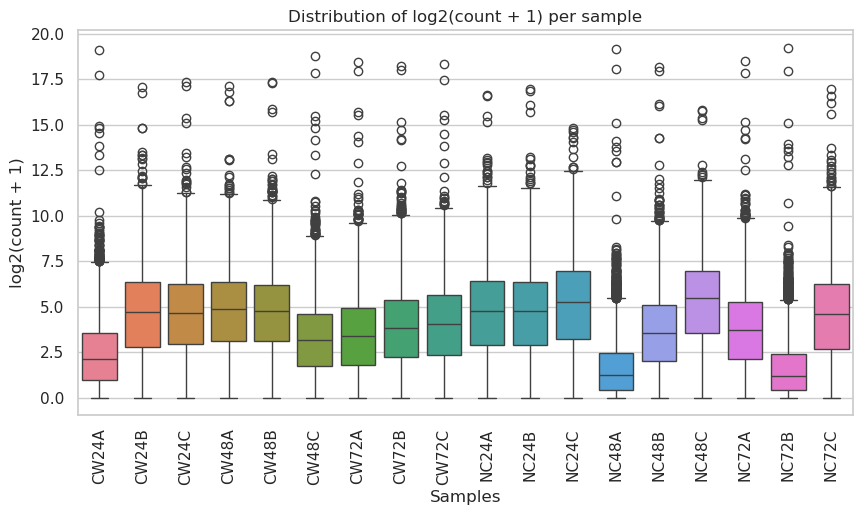

In [37]:
# figsize controls the width and height of the plot
plt.figure(figsize=(10,5))

# Create a boxplot showing the distribution of gene expression values for each sample
# log_cpm contains log2-transformed counts to reduce skewness of RNA-seq data
# Each box represents the distribution of gene expression values in a sample
sns.boxplot(data=log_cpm)

# Rotate sample labels on the x-axis to improve readability
plt.xticks(rotation=90)

# Add title and axis labels
plt.title("Distribution of log2(count + 1) per sample")
plt.xlabel("Samples")
plt.ylabel("log2(count + 1)")

# Display the figure
plt.show()

### Interpretation

Most samples display similar distributions of log-transformed gene expression values, indicating comparable sequencing depth and expression profiles across samples.

Two samples  (NC48A and NC72B) appears slightly shifted toward lower expression values, which may reflect differences in sequencing depth or biological variability. However, the overall distributions remain broadly consistent across samples.

Must keep it in mind when I'll processed with the analysis.

## Number of expressed genes per sample

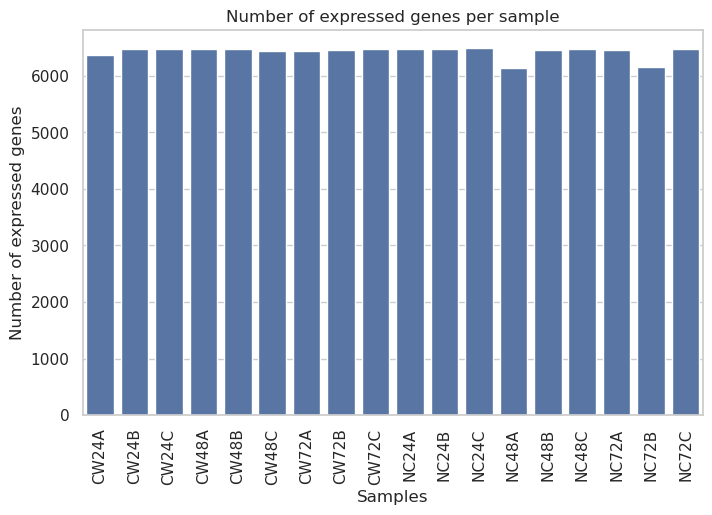

In [38]:
# (log_cpm > 0) creates a boolean matrix indicating whether each gene has at least one read
# sum(axis=0) counts how many genes are expressed in each sample
expressed_genes = (log_cpm > 0).sum(axis=0)

# Create a figure with a defined size
plt.figure(figsize=(8,5))

# Create a barplot showing the number of expressed genes per sample
# x-axis: sample names
# y-axis: number of genes with at least one read
sns.barplot(x=expressed_genes.index, y=expressed_genes.values)

# Rotate x-axis labels to improve readability
plt.xticks(rotation=90)

# Add plot title
plt.title("Number of expressed genes per sample")

# Label axes
plt.xlabel("Samples")
plt.ylabel("Number of expressed genes")

# Display the figure
plt.show()

### Interpretation

The number of expressed genes per sample ranges between approximately 6100 and 6500 genes. Overall, the number of detected genes is highly consistent across samples, indicating similar library complexity and sequencing coverage.

A small reduction in the number of expressed genes is observed in a few samples (the same as previously observed : NC48A and NC72B), but these differences remain minor and within the expected range for RNA-seq experiments. Therefore, no sample appears to suffer from a substantial loss of detectable gene expression.

## Sample correlation analysis

To assess the similarity between samples, we compute the correlation of gene expression profiles across all samples. High correlation between biological replicates and similar conditions is expected, while differences between experimental conditions may appear as distinct clusters.

### Initializing the correlation variable

In [39]:
corr = log_cpm.corr()
corr

,CW24A,CW24B,CW24C,CW48A,CW48B,CW48C,CW72A,CW72B,CW72C,NC24A,NC24B,NC24C,NC48A,NC48B,NC48C,NC72A,NC72B,NC72C
CW24A,1.000000,0.868534,0.905182,0.910688,0.908797,0.964613,0.968364,0.950475,0.951873,0.850597,0.889778,0.820221,0.964615,0.970922,0.793358,0.951431,0.983062,0.894570
CW24B,0.868534,1.000000,0.954964,0.941824,0.918619,0.898082,0.897776,0.936379,0.910474,0.939358,0.937059,0.954324,0.823248,0.898465,0.886213,0.934754,0.827225,0.941424
CW24C,0.905182,0.954964,1.000000,0.942375,0.955775,0.934054,0.933295,0.940713,0.932534,0.906380,0.934908,0.911111,0.866445,0.927589,0.854056,0.937756,0.864123,0.937964
CW48A,0.910688,0.941824,0.942375,1.000000,0.955118,0.951937,0.937939,0.965257,0.952928,0.898794,0.953353,0.916539,0.861382,0.957998,0.904966,0.964099,0.868836,0.940776
CW48B,0.908797,0.918619,0.955775,0.955118,1.000000,0.962808,0.937330,0.943898,0.928767,0.869789,0.936729,0.889770,0.863808,0.953868,0.892245,0.942400,0.870537,0.911278
CW48C,0.964613,0.898082,0.934054,0.951937,0.962808,1.000000,0.962678,0.964829,0.960262,0.858378,0.925948,0.854123,0.928625,0.978727,0.851461,0.969022,0.941349,0.918280
CW72A,0.968364,0.897776,0.933295,0.937939,0.937330,0.962678,1.000000,0.958700,0.951370,0.873562,0.948771,0.869264,0.951511,0.984167,0.849725,0.958507,0.938027,0.943625
CW72B,0.950475,0.936379,0.940713,0.965257,0.943898,0.964829,0.958700,1.000000,0.959076,0.897579,0.939402,0.895676,0.906271,0.970236,0.866050,0.994563,0.915913,0.940750
CW72C,0.951873,0.910474,0.932534,0.952928,0.928767,0.960262,0.951370,0.959076,1.000000,0.873724,0.911173,0.870856,0.898367,0.961846,0.848464,0.959442,0.916874,0.914599
NC24A,0.850597,0.939358,0.906380,0.898794,0.869789,0.858378,0.873562,0.897579,0.873724,1.000000,0.907096,0.952064,0.801725,0.867929,0.893201,0.894143,0.811138,0.902291


### Heat map of the correlation

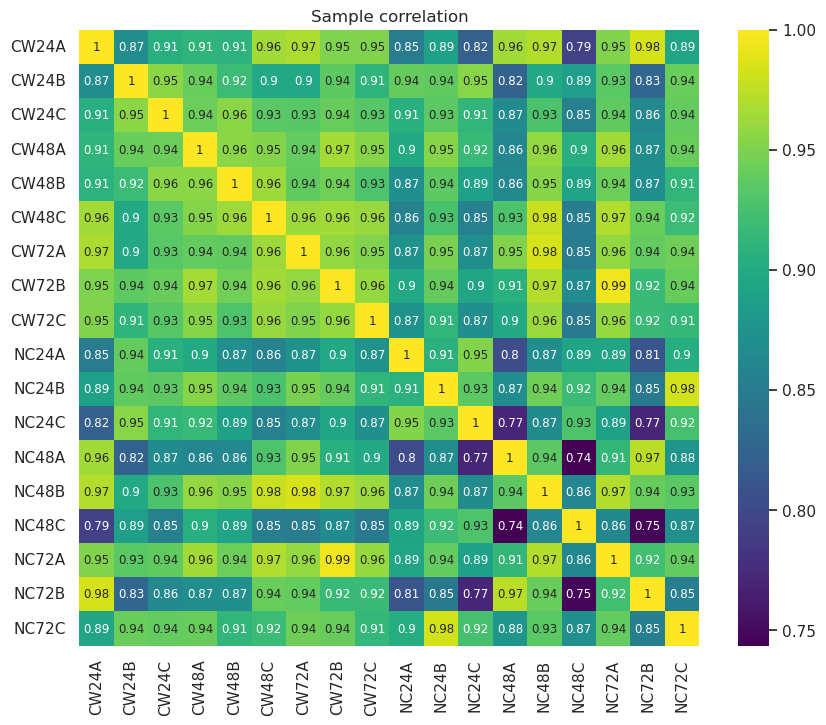

In [41]:
# Create a figure for the heatmap
# The figsize parameter controls the size of the plot (width, height)
plt.figure(figsize=(10,8))

# Plot the correlation matrix as a heatmap
# corr : matrix containing Pearson correlations between samples
# cmap="viridis" : color palette used to represent correlation values
# annot=True : display the numerical correlation values inside each cell
# annot_kws={"size":8.5} : adjust the font size of the annotations
sns.heatmap(corr, cmap="viridis", annot=True, annot_kws={"size":8.5})

# Add a title to the heatmap
plt.title("Sample correlation")

# Display the plot
plt.show()

#### Interpretation

The correlation heatmap shows strong similarity between most samples, with correlation coefficients generally ranging from approximately 0.85 to 0.99. Biological replicates within the same condition and time point display particularly high correlations, indicating consistent gene expression profiles across replicates.

A few samples, notably NC48A and NC72B, exhibit slightly lower correlations with some other samples. These observations are consistent with earlier exploratory analyses, where these samples showed minor deviations in expression distributions. However, their correlations remain relatively high overall, suggesting that these variations likely reflect normal biological or technical variability rather than clear outliers.

Overall, the dataset appears coherent and suitable for downstream multivariate analyses such as principal component analysis (PCA).

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical technique used to simplify complex datasets containing many variables. In RNA-seq experiments, thousands of genes are measured simultaneously, making it difficult to visualize relationships between samples directly.

PCA reduces this complexity by transforming the original data into a small number of new variables called *principal components*. Each component represents a direction that captures as much variation in the data as possible.

In practice, PCA allows us to project high-dimensional gene expression data onto a two-dimensional space, where each point represents a sample. Samples with similar expression profiles appear close to each other, while samples with different transcriptional patterns appear farther apart.

If experimental conditions influence gene expression, samples from the same condition are expected to cluster together in PCA space.

### PCA & Metadata preparation

In [42]:
# Extract sample names
samples = log_cpm.columns

# Perform PCA
pca = PCA(n_components=2)
X = pca.fit_transform(log_cpm.T)

# Extract metadata from sample names
conditions = []
timepoints = []

for s in samples:
    cond = "CW" if s.startswith("CW") else "NC"
    time = re.findall(r"\d+", s)[0]

    conditions.append(cond)
    timepoints.append(time)

# Define colors and marker shapes
color_map = {"CW": "tab:blue", "NC": "tab:red"}
marker_map = {"24": "o", "48": "s", "72": "^"}

### PCA Plot

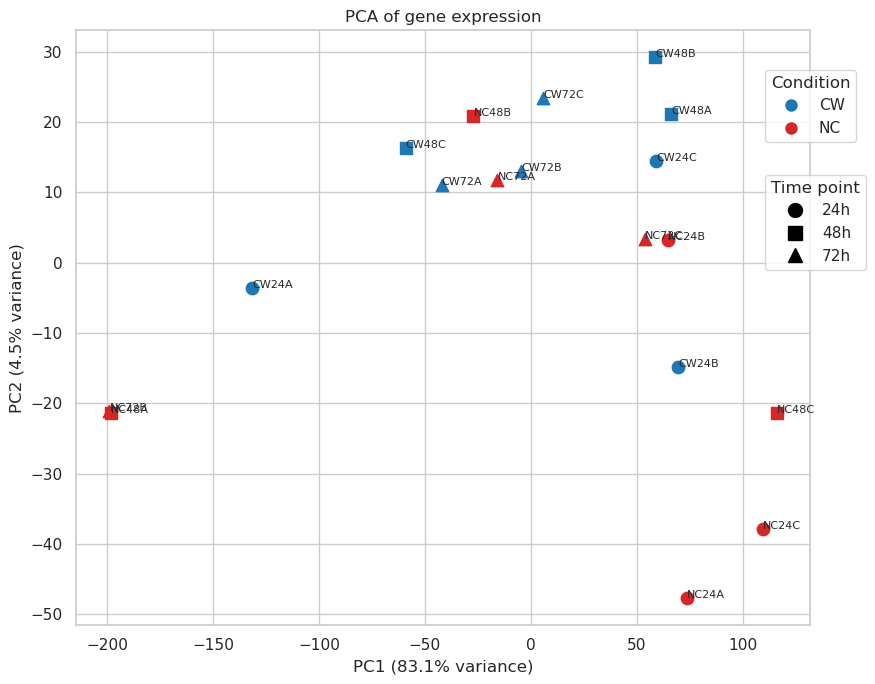

In [45]:
# Create the PCA figure
plt.figure(figsize=(9,7))

# Plot each sample in PCA space
for i, sample in enumerate(samples):
    plt.scatter(
        X[i,0],  # PC1 coordinate
        X[i,1],  # PC2 coordinate
        color=color_map[conditions[i]],     # color represents experimental condition (CW / NC)
        marker=marker_map[timepoints[i]],   # marker shape represents time point (24h / 48h / 72h)
        s=80                                # marker size
    )
    
    # Add sample name next to each point
    plt.text(X[i,0], X[i,1], sample, fontsize=8)

# Label PCA axes and indicate the variance explained
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of gene expression")


# Define legend for experimental conditions (colors)
condition_legend = [
    Line2D([0], [0], marker='o', color='w', label='CW',
           markerfacecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='NC',
           markerfacecolor='tab:red', markersize=10)
]

# Define legend for time points (marker shapes)
time_legend = [
    Line2D([0], [0], marker='o', color='black', label='24h', linestyle='None', markersize=10),
    Line2D([0], [0], marker='s', color='black', label='48h', linestyle='None', markersize=10),
    Line2D([0], [0], marker='^', color='black', label='72h', linestyle='None', markersize=10)
]

# Add legend for condition
legend1 = plt.legend(
    handles=condition_legend,
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.9),
    bbox_transform=plt.gcf().transFigure
)

# Add legend for time points
legend2 = plt.legend(
    handles=time_legend,
    title="Time point",
    loc="upper left",
    bbox_to_anchor=(0.85, 0.75),
    bbox_transform=plt.gcf().transFigure
)

# Ensure both legends appear on the figure
plt.gca().add_artist(legend1)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the PCA plot
plt.show()

### Interpretation

Principal Component Analysis reveals the major sources of variation in the dataset.

Samples tend to cluster according to biological condition and timepoint, suggesting that oxidative stress induces a coordinated transcriptional response in *Pseudomonas aeruginosa*.

The separation observed along the first principal components indicates that a subset of genes drives the transcriptional differences between the chronic wound (CW) environment and the control condition (NC).

This confirms that the dataset contains biologically meaningful signal rather than random variation.

## Gene expression variability

To identify genes that contribute most strongly to transcriptional variability, we calculate the variance of gene expression across samples. Highly variable genes often capture biologically relevant differences between conditions.

In [46]:
# Calculate variance of gene expression across samples
gene_var = log_cpm.var(axis=1)

# Display the first genes
gene_var.head()

Geneid
EKIOKJ_00005.t01    1.158258
EKIOKJ_00010.t01    1.263751
EKIOKJ_00015.t01    1.197950
EKIOKJ_00020.t01    1.534070
EKIOKJ_00025.t01    1.263810
dtype: float64

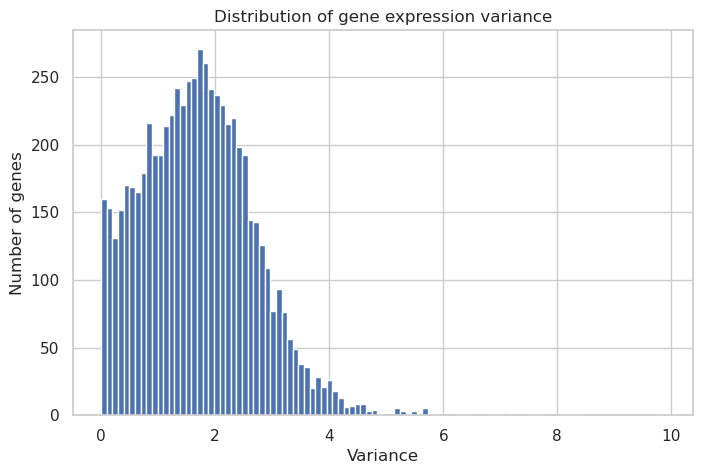

In [47]:
# Create a figure to visualize the distribution of gene expression variance
plt.figure(figsize=(8,5))

# Plot a histogram showing how gene expression variance is distributed across genes
plt.hist(gene_var, bins=100)

# Add title and axis labels
plt.title("Distribution of gene expression variance")
plt.xlabel("Variance")
plt.ylabel("Number of genes")

# Display the figure
plt.show()

#### Interpretation
This histogram shows the distribution of gene expression variance across all genes. 
Most genes display relatively low variance across samples, indicating relatively stable expression levels, while a smaller subset of genes shows higher variability.

### Top Variance Genes

Highly variable genes are often the main drivers of transcriptional differences between samples. 
For this reason, the next step focuses on identifying the genes with the highest variance across the dataset.

These genes are more likely to capture biologically meaningful variation between experimental conditions and may contribute to the transcriptional patterns observed in the PCA analysis.

In [48]:
# Identify the genes with the highest expression variance
# Genes are sorted from highest to lowest variance
# The top 50 most variable genes are selected
top_var_genes = gene_var.sort_values(ascending=False).head(50)

#Display the selected genes
top_var_genes

Geneid
EKIOKJ_19330.t01    9.885377
EKIOKJ_19325.t01    8.338031
EKIOKJ_19335.t01    8.230489
EKIOKJ_25280.t01    8.045120
EKIOKJ_25275.t01    7.688390
EKIOKJ_27705.t01    7.603327
EKIOKJ_27700.t01    7.105577
EKIOKJ_23755.t01    7.051147
EKIOKJ_31930.t01    6.846775
EKIOKJ_07900.t01    6.378138
EKIOKJ_28190.t01    6.167479
EKIOKJ_22800.t01    6.139010
EKIOKJ_03890.t01    6.113397
EKIOKJ_25270.t01    6.032584
EKIOKJ_25200.t01    5.729268
EKIOKJ_17725.t01    5.696091
EKIOKJ_04195.t01    5.668284
EKIOKJ_27710.t01    5.663434
EKIOKJ_17730.t01    5.645947
EKIOKJ_05945.t01    5.570593
EKIOKJ_32320.t01    5.494144
EKIOKJ_17710.t01    5.486118
EKIOKJ_26430.t01    5.441678
EKIOKJ_25260.t01    5.363306
EKIOKJ_12265.t01    5.328915
EKIOKJ_00815.t01    5.294063
EKIOKJ_03735.t01    5.269295
EKIOKJ_25985.r01    5.231427
EKIOKJ_05940.t01    5.224268
EKIOKJ_26435.t01    5.222092
EKIOKJ_06430.t01    5.203375
EKIOKJ_08830.t01    5.141445
EKIOKJ_03095.t01    5.135189
EKIOKJ_25205.t01    5.085894
EKIOKJ_

#### Interpretation
The table above lists the genes with the highest expression variance across samples. High variance indicates that the expression levels of these genes vary strongly between samples.

Such genes are particularly informative because they are more likely to contribute to transcriptional differences observed in exploratory analyses such as PCA and clustering.

However, high variance alone does not indicate whether these genes are specifically associated with the CW or NC condition. Further analysis is required to determine whether their expression differences are statistically significant between experimental groups.

### Hierarchical clustering of the 50 most variable genes across samples

In [49]:
# Sample metadata preparation

# Extract sample names
samples = log_cpm.columns

# Extract condition and time point from sample names
conditions = []
timepoints = []

for s in samples:
    cond = "CW" if s.startswith("CW") else "NC"
    time = re.findall(r"\d+", s)[0]

    conditions.append(cond)
    timepoints.append(time)

# Create a metadata table for samples
sample_metadata = pd.DataFrame({
    "Condition": conditions,
    "Time": timepoints
}, index=samples)

# Define color palettes for annotations
condition_palette = {
    "CW": "tab:blue",
    "NC": "tab:red"
}

time_palette = {
    "24": "#4daf4a",
    "48": "#ff7f00",
    "72": "#984ea3"
}

# Map metadata values to colors
col_colors = pd.DataFrame({
    "Condition": sample_metadata["Condition"].map(condition_palette),
    "Time": sample_metadata["Time"].map(time_palette)
}, index=samples)

sample_metadata.head()

,Condition,Time
CW24A,CW,24
CW24B,CW,24
CW24C,CW,24
CW48A,CW,48
CW48B,CW,48


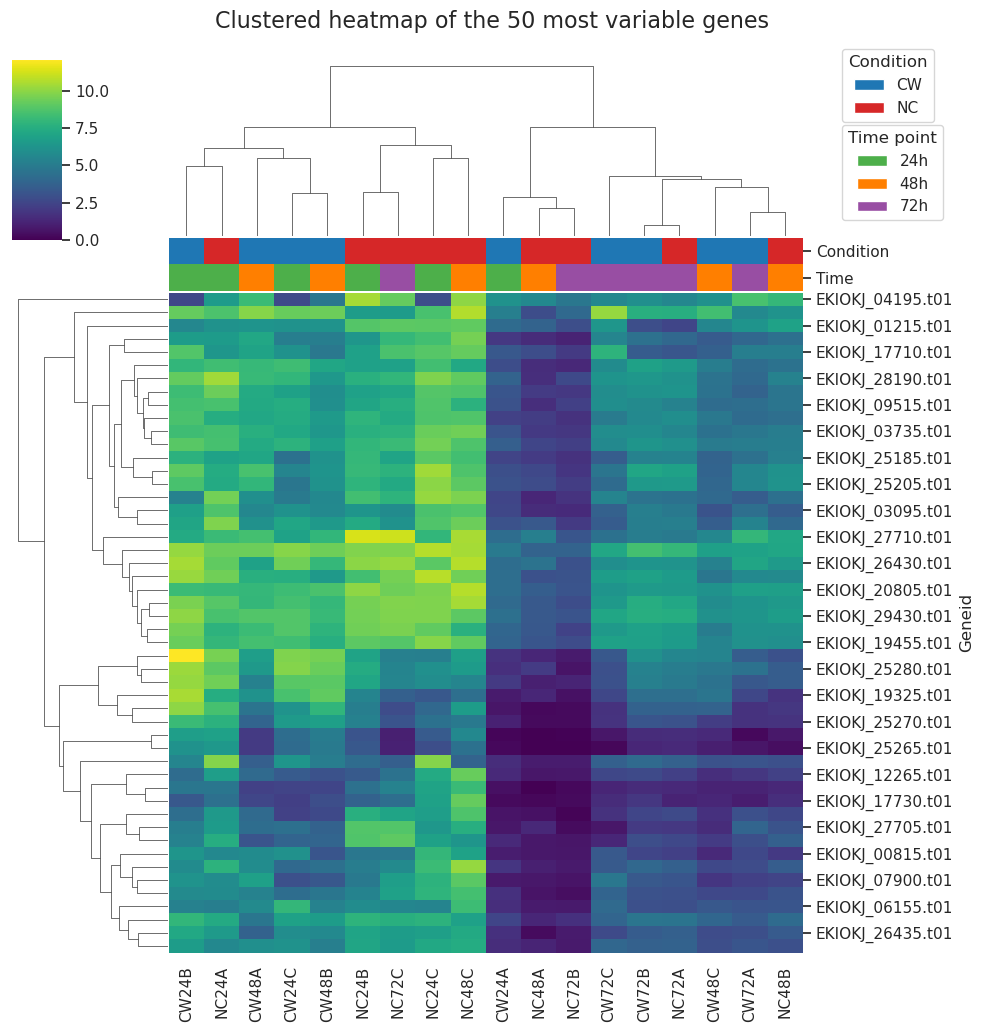

In [52]:
from matplotlib.patches import Patch

# Select the most variable genes
top_genes = top_var_genes.index

# Create clustered heatmap with sample annotations
g = sns.clustermap(
    log_cpm.loc[top_genes],
    cmap="viridis",
    col_colors=col_colors,
    figsize=(10,10)
)

# Create legend for experimental condition
condition_legend = [
    Patch(facecolor="tab:blue", label="CW"),
    Patch(facecolor="tab:red", label="NC")
]

# Create legend for time points
time_legend = [
    Patch(facecolor="#4daf4a", label="24h"),
    Patch(facecolor="#ff7f00", label="48h"),
    Patch(facecolor="#984ea3", label="72h")
]

# Condition legend
legend1 = g.ax_heatmap.legend(
    handles=condition_legend,
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(1.05, 1.38)
);

# Time legend
legend2 = g.ax_heatmap.legend(
    handles=time_legend,
    title="Time point",
    loc="upper left",
    bbox_to_anchor=(1.05, 1.265)
);

g.fig.suptitle(
    "Clustered heatmap of the 50 most variable genes",
    fontsize=16,
    y=1.03
);

g.ax_heatmap.add_artist(legend1);

#### Interpretation

This heatmap displays the expression patterns of the 50 most variable genes across all samples. Hierarchical clustering was applied both to genes (rows) and samples (columns), grouping together elements with similar expression profiles.

The clustering reveals several coherent expression patterns among genes, indicating that subsets of genes share similar transcriptional behavior across samples. These patterns may reflect coordinated biological responses.

At the sample level, the clustering does not produce a strict separation between CW and NC conditions. Instead, samples appear partially intermixed, suggesting that gene expression variability may be influenced by multiple factors such as experimental condition, time point, or biological variability.

Some samples appear slightly more distinct in their expression profiles, which is consistent with earlier exploratory analyses (correlation matrix and PCA) that indicated potential variability among certain samples.

Overall, the heatmap confirms the presence of structured transcriptional variation in the dataset and highlights subsets of genes that may contribute to differences between samples.

# Differential Expression Analysis (DEA)
After exploring the overall structure of the dataset through exploratory analyses (PCA, correlation, and clustering), the next step is to formally test for genes that show significant differences in expression between experimental conditions.

Differential expression analysis aims to identify genes whose expression levels differ between bacteria collected from **chronic wounds (CW)** and **non-chronic wounds (NC)**. For each gene, the average expression between the two groups is compared, and statistical tests are used to determine whether the observed differences are significant.

This analysis produces two key metrics:

- **log2 fold change (log2FC)**, which quantifies the magnitude and direction of expression change between conditions.
- **p-values**, which assess the statistical significance of the observed differences.

Together, these metrics allow the identification of genes that are significantly **upregulated** or **downregulated** between CW and NC samples. These genes may play important roles in the bacterial response to oxidative stress and in the establishment of chronic wound infections.

## Group definition

To compare gene expression between chronic wound (CW) and non-chronic wound (NC) conditions, samples are first grouped according to their condition.

In [53]:
# Define sample groups based on condition
cw_samples = [s for s in samples if s.startswith("CW")]
nc_samples = [s for s in samples if s.startswith("NC")]

# Display grouped samples
cw_samples, nc_samples

(['CW24A',
  'CW24B',
  'CW24C',
  'CW48A',
  'CW48B',
  'CW48C',
  'CW72A',
  'CW72B',
  'CW72C'],
 ['NC24A',
  'NC24B',
  'NC24C',
  'NC48A',
  'NC48B',
  'NC48C',
  'NC72A',
  'NC72B',
  'NC72C'])

## Mean expression and log2 fold change

To estimate how gene expression differs between the two conditions, the average expression level of each gene is calculated separately for CW and NC samples.

The difference between these averages is then expressed as a **log2 fold change (log2FC)**. Positive values indicate higher expression in CW, while negative values indicate higher expression in NC.

In [54]:
# Calculate mean expression for each gene in CW and NC samples
cw_mean = log_cpm[cw_samples].mean(axis=1)
nc_mean = log_cpm[nc_samples].mean(axis=1)

# Compute log2 fold change (CW vs NC)
log2_fc = cw_mean - nc_mean

# Combine results into a dataframe
dea_results = pd.DataFrame({
    "CW_mean": cw_mean,
    "NC_mean": nc_mean,
    "log2FC": log2_fc
})

dea_results.head()

,CW_mean,NC_mean,log2FC
Geneid,,,
EKIOKJ_00005.t01,5.140946,4.202983,0.937964
EKIOKJ_00010.t01,4.619557,4.352724,0.266834
EKIOKJ_00015.t01,4.920634,3.873703,1.046932
EKIOKJ_00020.t01,3.157580,3.322089,-0.164509
EKIOKJ_00025.t01,2.731803,2.567324,0.164479


## Statistical testing

To determine whether the observed differences in gene expression between CW and NC samples are statistically significant, an independent two-sample t-test is performed for each gene.

This test compares the expression values across the two groups and produces a **p-value**, which estimates the probability that the observed difference occurred by chance.

Lower p-values indicate stronger evidence that a gene is differentially expressed between conditions.

In [55]:
# Initialize an empty list to store p-values for each gene
p_values = []

# Loop through all genes in the dataset
for gene in log_cpm.index:
    
    # Extract expression values for the current gene in CW samples
    cw_values = log_cpm.loc[gene, cw_samples]
    
    # Extract expression values for the same gene in NC samples
    nc_values = log_cpm.loc[gene, nc_samples]
    
    # Perform Welch's t-test
    stat, p = ttest_ind(cw_values, nc_values, equal_var=False)
    
    # Store p-value
    p_values.append(p)

# Add p-values to DEA results table
dea_results["p_value"] = p_values
dea_results["padj"] = multipletests(dea_results["p_value"], method="fdr_bh")[1]

# Display result
dea_results.head()

,CW_mean,NC_mean,log2FC,p_value,padj
Geneid,,,,,
EKIOKJ_00005.t01,5.140946,4.202983,0.937964,0.063735,0.999753
EKIOKJ_00010.t01,4.619557,4.352724,0.266834,0.631331,0.999753
EKIOKJ_00015.t01,4.920634,3.873703,1.046932,0.038456,0.999753
EKIOKJ_00020.t01,3.157580,3.322089,-0.164509,0.788165,0.999753
EKIOKJ_00025.t01,2.731803,2.567324,0.164479,0.767295,0.999753


### Remarque
For simplicity, differential expression was assessed using independent t-tests on log-transformed expression values. In full RNA-seq analyses, specialized methods such as DESeq2 or edgeR are typically used, along with multiple testing correction. Here, p-values are reported to illustrate the principle of differential expression analysis in an exploratory context.

## Volcano plot

A volcano plot combines the magnitude of expression change and the statistical significance of that change for each gene.

- The x-axis shows the **log2 fold change (log2FC)** between CW and NC.
- The y-axis shows **-log10(p_value)**, so that more statistically significant genes appear higher on the plot.

Genes located far from the center and high on the plot are the most likely to show meaningful differential expression between conditions.

In [56]:
# Create significance categories for exploratory volcano plot
dea_results["significance"] = "Not significant"

dea_results.loc[
    (dea_results["log2FC"] > 0.5) & (dea_results["p_value"] < 0.05),
    "significance"
] = "Up in CW"

dea_results.loc[
    (dea_results["log2FC"] < -0.5) & (dea_results["p_value"] < 0.05),
    "significance"
] = "Up in NC"

dea_results["minus_log10_pvalue"] = -np.log10(dea_results["p_value"])

color_map_volcano = {
    "Not significant": "lightgrey",
    "Up in CW": "red",
    "Up in NC": "blue"
}

# Select genes significantly upregulated in CW
top_cw_genes = dea_results[dea_results["significance"] == "Up in CW"].copy()

# Sort genes by p-value (most significant first)
top_cw_genes = top_cw_genes.sort_values("p_value")

# Keep the top 10 most significant genes
top_10_cw_genes = top_cw_genes.head(10)

# Display the result table
top_10_cw_genes

,CW_mean,NC_mean,log2FC,p_value,padj,significance,minus_log10_pvalue
Geneid,,,,,,,
EKIOKJ_24785.t01,4.083145,2.714594,1.368551,0.003496,0.999753,Up in CW,2.456460
EKIOKJ_03910.t01,6.487840,5.425789,1.062051,0.004765,0.999753,Up in CW,2.321924
EKIOKJ_30745.t01,5.180163,3.888139,1.292023,0.006011,0.999753,Up in CW,2.221050
EKIOKJ_00570.t01,4.695848,3.477291,1.218558,0.007430,0.999753,Up in CW,2.129022
EKIOKJ_00580.t01,6.120488,4.611578,1.508911,0.007646,0.999753,Up in CW,2.116557
EKIOKJ_32255.t01,7.907673,6.066061,1.841612,0.007818,0.999753,Up in CW,2.106909
EKIOKJ_00575.t01,4.336945,3.040380,1.296565,0.008048,0.999753,Up in CW,2.094298
EKIOKJ_21410.t01,7.220422,5.216229,2.004193,0.008596,0.999753,Up in CW,2.065710
EKIOKJ_21415.t01,8.280734,6.472778,1.807956,0.008825,0.999753,Up in CW,2.054295


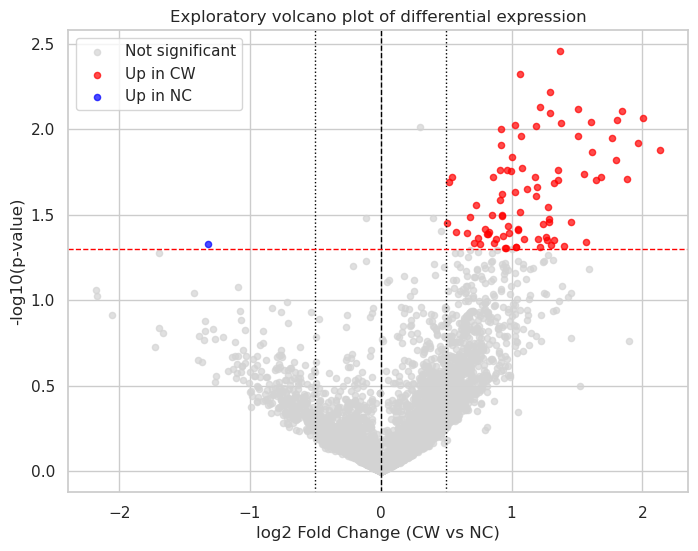

In [59]:
plt.figure(figsize=(8,6))

for category, color in color_map_volcano.items():
    subset = dea_results[dea_results["significance"] == category]
    plt.scatter(
        subset["log2FC"],
        subset["minus_log10_pvalue"],
        color=color,
        label=category,
        alpha=0.7,
        s=20
    )

plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.axvline(x=0.5, color="black", linestyle=":", linewidth=1)
plt.axvline(x=-0.5, color="black", linestyle=":", linewidth=1)
plt.axhline(y=-np.log10(0.05), color="red", linestyle="--", linewidth=1)

plt.xlabel("log2 Fold Change (CW vs NC)")
plt.ylabel("-log10(p-value)")
plt.title("Exploratory volcano plot of differential expression")
plt.legend()
plt.show()

### Interpretation 

The volcano plot visualizes the relationship between expression fold change and statistical significance for all genes in the dataset.

Most genes cluster around log2FC ≈ 0 with relatively low statistical significance, indicating that the majority of genes show similar expression levels between CW and NC samples.

However, a subset of genes displays both higher fold change and stronger statistical significance. In particular, several genes show increased expression in CW samples (log2FC > 1 and p-value < 0.05), suggesting that the chronic wound environment may induce specific transcriptional responses in *Pseudomonas aeruginosa*.

Conversely, very few genes meet the criteria for higher expression in NC samples, indicating that transcriptional activation appears to be stronger under chronic wound conditions.

*(Because this exploratory analysis uses a simplified t-test framework across all timepoints, adjusted p-values were highly conservative. For visualization purposes, the volcano plot below is shown using raw p-values, while acknowledging that these results are exploratory rather than definitive.)*

In [60]:
top_10_cw_genes

,CW_mean,NC_mean,log2FC,p_value,padj,significance,minus_log10_pvalue
Geneid,,,,,,,
EKIOKJ_24785.t01,4.083145,2.714594,1.368551,0.003496,0.999753,Up in CW,2.456460
EKIOKJ_03910.t01,6.487840,5.425789,1.062051,0.004765,0.999753,Up in CW,2.321924
EKIOKJ_30745.t01,5.180163,3.888139,1.292023,0.006011,0.999753,Up in CW,2.221050
EKIOKJ_00570.t01,4.695848,3.477291,1.218558,0.007430,0.999753,Up in CW,2.129022
EKIOKJ_00580.t01,6.120488,4.611578,1.508911,0.007646,0.999753,Up in CW,2.116557
EKIOKJ_32255.t01,7.907673,6.066061,1.841612,0.007818,0.999753,Up in CW,2.106909
EKIOKJ_00575.t01,4.336945,3.040380,1.296565,0.008048,0.999753,Up in CW,2.094298
EKIOKJ_21410.t01,7.220422,5.216229,2.004193,0.008596,0.999753,Up in CW,2.065710
EKIOKJ_21415.t01,8.280734,6.472778,1.807956,0.008825,0.999753,Up in CW,2.054295


### Interpretation

The top genes identified in this analysis show substantial increases in expression in CW samples compared to NC samples, with log2 fold changes ranging from approximately 1.1 to over 2.1.

These genes represent potential candidates involved in the bacterial response to chronic wound conditions. Such responses may include oxidative stress adaptation, virulence regulation, or biofilm formation, which are known mechanisms used by *Pseudomonas aeruginosa* to persist in hostile environments.

# Overall conclusions



# Conclusion

This project explored transcriptional responses of *Pseudomonas aeruginosa* under oxidative stress conditions associated with chronic wounds using RNA-seq data.

The analysis pipeline included:

- data loading and cleaning
- exploratory data analysis
- library size assessment
- normalization of counts
- dimensionality reduction (PCA)
- identification of highly variable genes
- differential expression analysis
- visualization using heatmaps and volcano plots

The results highlight substantial transcriptional variability across samples and reveal genes significantly associated with oxidative stress conditions.

Although simplified statistical methods were used here compared to specialized RNA-seq tools such as DESeq2 or edgeR, this analysis demonstrates how Python-based data science workflows can extract meaningful biological insights from high-dimensional genomic datasets.

From a data science perspective, this project illustrates:

- handling high-dimensional biological data
- building reproducible analysis pipelines
- applying statistical testing at scale
- visualizing complex datasets

These techniques are broadly transferable to many data-intensive fields beyond bioinformatics.

## Biological interpretation

The exploratory analysis reveals several genes with increased expression in CW samples compared to NC samples.

These genes may be associated with the bacterial response to oxidative stress conditions encountered in chronic wound environments.

However, this analysis uses a simplified statistical framework based on independent t-tests and therefore should be interpreted cautiously.

More robust RNA-seq differential expression analysis would typically involve specialized methods such as DESeq2 or edgeR.

Nevertheless, this workflow successfully demonstrates the ability to explore high-dimensional biological data and identify candidate genes for further investigation.

## Data Science Skills Demonstrated

This project demonstrates several core data science skills:

• Data wrangling and preprocessing of large biological datasets  
• Exploratory data analysis and visualization  
• Dimensionality reduction (PCA)  
• Statistical hypothesis testing  
• Multiple testing correction  
• Interpretation of high-dimensional data  
• Reproducible research using Python and Jupyter

## Limitations of the analysis

This notebook implements a simplified RNA-seq analysis pipeline.

Key limitations include:

- use of a t-test instead of specialized RNA-seq models
- pooling of samples across timepoints
- absence of gene annotation due to incompatible gene identifiers

Despite these limitations, the workflow demonstrates the key steps involved in exploring high-dimensional transcriptomic datasets.